In [4]:
import os, pickle, random
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
 
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Paths

In [5]:
DATA_ROOT     = Path("/kaggle/input/datasets/sahilakolte/vr-project-1/dataset/processed")
TRAIN_IMG_DIR = DATA_ROOT / "train"      / "images"
VAL_IMG_DIR   = DATA_ROOT / "validation" / "images"
CKPT_DIR      = Path("/kaggle/working/mobilenet_transfer")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

Load pkl files

In [6]:
with open(DATA_ROOT / "train_labels.pkl", "rb") as f:
    train_labels = pickle.load(f)
with open(DATA_ROOT / "val_labels.pkl", "rb") as f:
    val_labels = pickle.load(f)
with open(DATA_ROOT / "class_weights.pkl", "rb") as f:
    class_weights_data = pickle.load(f)
with open(DATA_ROOT / "top5.pkl", "rb") as f:
    top5_data = pickle.load(f)
with open(DATA_ROOT / "label_map.pkl", "rb") as f:
    label_map = pickle.load(f)
 
print("train_labels — type:", type(train_labels), " len:", len(train_labels))
print("top5_data   :", top5_data)
print("label_map   :", label_map)


train_labels — type: <class 'dict'>  len: 144174
top5_data   : [1, 8, 7, 2, 9]
label_map   : {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


Class names

In [7]:
ALL_CATEGORIES = {
    1:"short_sleeve_top",    2:"long_sleeve_top",
    3:"short_sleeve_outwear",4:"long_sleeve_outwear",
    5:"vest",                6:"sling",
    7:"shorts",              8:"trousers",
    9:"skirt",               10:"short_sleeve_dress",
    11:"long_sleeve_dress",  12:"vest_dress",
    13:"sling_dress"
}
CLASS_NAMES = [ALL_CATEGORIES[cat_id] for cat_id in top5_data]
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")


Classes (5): ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']


Build records

In [8]:
def build_records(labels_dict, img_dir):
    records = []
    for filename, label_arr in labels_dict.items():
        img_path = img_dir / filename
        if not img_path.exists():
            continue
        records.append({
            "img_path":   str(img_path),
            "multilabel": list(np.array(label_arr, dtype=np.float32)),
        })
    return records
 
train_records = build_records(train_labels, TRAIN_IMG_DIR)
val_records   = build_records(val_labels,   VAL_IMG_DIR)


Stratified sampling

In [9]:
def stratified_sample(records, fraction=1, num_classes=5,
                       min_per_class=500, seed=42):
    """
    Sample fraction of records while keeping per-class balance.
    Guarantees at least min_per_class images per class.
    """
    random.seed(seed)
    class_buckets = {i: [] for i in range(num_classes)}
    for rec in records:
        for i, v in enumerate(rec["multilabel"]):
            if v == 1.0:
                class_buckets[i].append(rec)
 
    print("Class distribution BEFORE sampling:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: {len(class_buckets[i])}")
 
    sampled = {}
    for i in range(num_classes):
        bucket = class_buckets[i]
        n      = max(min_per_class, int(len(bucket) * fraction))
        chosen = random.sample(bucket, min(n, len(bucket)))
        for rec in chosen:
            sampled[rec["img_path"]] = rec
 
    result = list(sampled.values())
    random.shuffle(result)
 
    print(f"\nAfter sampling: {len(result)}/{len(records)} "
          f"({len(result)/len(records)*100:.1f}%)")
    print("Class distribution AFTER sampling:")
    for i, name in enumerate(CLASS_NAMES):
        count = sum(1 for r in result if r["multilabel"][i] == 1.0)
        print(f"  [{i}] {name:<28s}: {count}")
    return result
 
train_records = train_records
 
# Val/test split — no sampling needed
random.shuffle(val_records)
mid          = len(val_records) // 2
test_records = val_records[mid:]
val_records  = val_records[:mid]
 
print(f"\nFinal — Train:{len(train_records)}  Val:{len(val_records)}  Test:{len(test_records)}")
assert len(train_records) > 0, "No training images found — check DATA_ROOT"
 


Final — Train:144174  Val:11870  Test:11871


Class weights

In [10]:
if isinstance(class_weights_data, dict):
    sorted_w    = [v for _, v in sorted(class_weights_data.items())]
    pos_weights = np.array(sorted_w[:NUM_CLASSES], dtype=np.float32)
elif isinstance(class_weights_data, (list, np.ndarray)):
    pos_weights = np.array(class_weights_data, dtype=np.float32)
else:
    pos_weights = np.ones(NUM_CLASSES, dtype=np.float32)
 
if len(pos_weights) != NUM_CLASSES:
    print("Recomputing class weights from sampled training data...")
    all_labels   = np.array([r["multilabel"] for r in train_records])
    class_counts = all_labels.sum(axis=0)
    N            = len(train_records)
    pos_weights  = ((N - class_counts) / (class_counts + 1e-6)).astype(np.float32)
 
pos_weights_t = torch.tensor(pos_weights).to(device)
print(f"pos_weights: {pos_weights}")


pos_weights: [0.40850595 0.52456474 0.79364747 0.80654526 0.9415445 ]


Dataset

In [11]:
class ApparelDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records
        self.transform = transform
 
    def __len__(self):
        return len(self.records)
 
    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = Image.open(rec["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (160, 160), 0)
        label = torch.tensor(rec["multilabel"], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label
 
IMG_SIZE = 160   # smaller = faster
 
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
 
train_ds = ApparelDataset(train_records, train_transform)
val_ds   = ApparelDataset(val_records,   val_transform)
test_ds  = ApparelDataset(test_records,  val_transform)
 
BATCH_SIZE   = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
print(f"Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")


Batches — train:2253  val:186  test:186


Model

In [12]:
model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)
print(f"MobileNetV3-Large (transfer) — params: {sum(p.numel() for p in model.parameters()):,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 134MB/s] 


MobileNetV3-Large (transfer) — params: 4,208,437


Loss & helpers

In [13]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_t)
 
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)
 
@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Eval", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels).astype(int)
    preds  = (probs >= threshold).astype(int)
    return (total_loss / len(loader.dataset),
            f1_score(labels, preds, average="micro", zero_division=0),
            f1_score(labels, preds, average="macro", zero_division=0),
            probs, labels)
 
def freeze_backbone(model):
    for name, param in model.named_parameters():
        param.requires_grad = "classifier" in name
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone frozen — trainable params: {n:,}")
 
def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"All unfrozen — trainable params: {n:,}")


Phase 1 — Head only (5 epochs

In [14]:
PHASE1    = 5
PHASE2    = 20
PATIENCE  = 4
best_f1   = 0.0
no_improve = 0
history   = {"train_loss": [], "val_loss": [], "micro_f1": [], "macro_f1": []}
 
print("\n── Phase 1: Frozen backbone, head only ──")
freeze_backbone(model)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
 
for epoch in range(1, PHASE1 + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, micro_f1, macro_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["micro_f1"].append(micro_f1)
    history["macro_f1"].append(macro_f1)
    print(f"[P1] Epoch {epoch:02d}/{PHASE1} | Train:{tr_loss:.4f} | "
          f"Val:{va_loss:.4f} | Micro-F1:{micro_f1:.4f} | Macro-F1:{macro_f1:.4f}")
    if macro_f1 > best_f1:
        best_f1 = macro_f1; no_improve = 0
        torch.save({"epoch": epoch, "phase": 1, "model_state": model.state_dict(),
                    "macro_f1": macro_f1, "class_names": CLASS_NAMES},
                   CKPT_DIR / "best_model.pt")
        print(f"  ✓ Saved (Macro-F1={macro_f1:.4f})")



── Phase 1: Frozen backbone, head only ──
Backbone frozen — trainable params: 1,236,485


[P1] Epoch 01/5 | Train:0.3869 | Val:0.3816 | Micro-F1:0.4368 | Macro-F1:0.3734
  ✓ Saved (Macro-F1=0.3734)


[P1] Epoch 02/5 | Train:0.3736 | Val:0.3746 | Micro-F1:0.4474 | Macro-F1:0.4140
  ✓ Saved (Macro-F1=0.4140)


[P1] Epoch 03/5 | Train:0.3624 | Val:0.3640 | Micro-F1:0.4705 | Macro-F1:0.4521
  ✓ Saved (Macro-F1=0.4521)


[P1] Epoch 04/5 | Train:0.3594 | Val:0.3634 | Micro-F1:0.4512 | Macro-F1:0.4257


[P1] Epoch 05/5 | Train:0.3543 | Val:0.3660 | Micro-F1:0.4755 | Macro-F1:0.4539
  ✓ Saved (Macro-F1=0.4539)


Phase 2 — Full fine-tuning

In [15]:
print("\n── Phase 2: Full fine-tuning ──")
unfreeze_all(model)
no_improve = 0
 
backbone_params = [p for n, p in model.named_parameters() if "classifier" not in n]
head_params     = [p for n, p in model.named_parameters() if "classifier"     in n]
optimizer = optim.Adam([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params,     "lr": 1e-3},
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2, eta_min=1e-6)
 
for epoch in range(1, PHASE2 + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, micro_f1, macro_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["micro_f1"].append(micro_f1)
    history["macro_f1"].append(macro_f1)
    print(f"[P2] Epoch {epoch:02d}/{PHASE2} | Train:{tr_loss:.4f} | "
          f"Val:{va_loss:.4f} | Micro-F1:{micro_f1:.4f} | Macro-F1:{macro_f1:.4f}")
    if macro_f1 > best_f1:
        best_f1 = macro_f1; no_improve = 0
        torch.save({"epoch": PHASE1 + epoch, "phase": 2,
                    "model_state": model.state_dict(),
                    "macro_f1": macro_f1, "class_names": CLASS_NAMES},
                   CKPT_DIR / "best_model.pt")
        print(f"  ✓ Saved (Macro-F1={macro_f1:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("Early stopping."); break
 
print(f"\nBest Val Macro-F1: {best_f1:.4f}")


── Phase 2: Full fine-tuning ──
All unfrozen — trainable params: 4,208,437


[P2] Epoch 01/20 | Train:0.2720 | Val:0.2389 | Micro-F1:0.7567 | Macro-F1:0.7377
  ✓ Saved (Macro-F1=0.7377)


[P2] Epoch 02/20 | Train:0.2136 | Val:0.2163 | Micro-F1:0.7948 | Macro-F1:0.7789
  ✓ Saved (Macro-F1=0.7789)


[P2] Epoch 03/20 | Train:0.1880 | Val:0.2106 | Micro-F1:0.8034 | Macro-F1:0.7902
  ✓ Saved (Macro-F1=0.7902)


[P2] Epoch 04/20 | Train:0.1698 | Val:0.2135 | Micro-F1:0.7985 | Macro-F1:0.7907
  ✓ Saved (Macro-F1=0.7907)


...

[P2] Epoch 14/20 | Train:0.0739 | Val:0.2791 | Micro-F1:0.8220 | Macro-F1:0.8102
  ✓ Saved (Macro-F1=0.8102)


[P2] Epoch 15/20 | Train:0.0683 | Val:0.2938 | Micro-F1:0.8185 | Macro-F1:0.8056
  No improvement (1/4)


[P2] Epoch 16/20 | Train:0.0637 | Val:0.2992 | Micro-F1:0.8203 | Macro-F1:0.8066
  No improvement (2/4)


[P2] Epoch 17/20 | Train:0.0593 | Val:0.3003 | Micro-F1:0.8211 | Macro-F1:0.8090
  No improvement (3/4)


[P2] Epoch 18/20 | Train:0.0571 | Val:0.3098 | Micro-F1:0.8201 | Macro-F1:0.8083
  No improvement (4/4)
Early stopping.

Best Val Macro-F1: 0.8102


Training curves

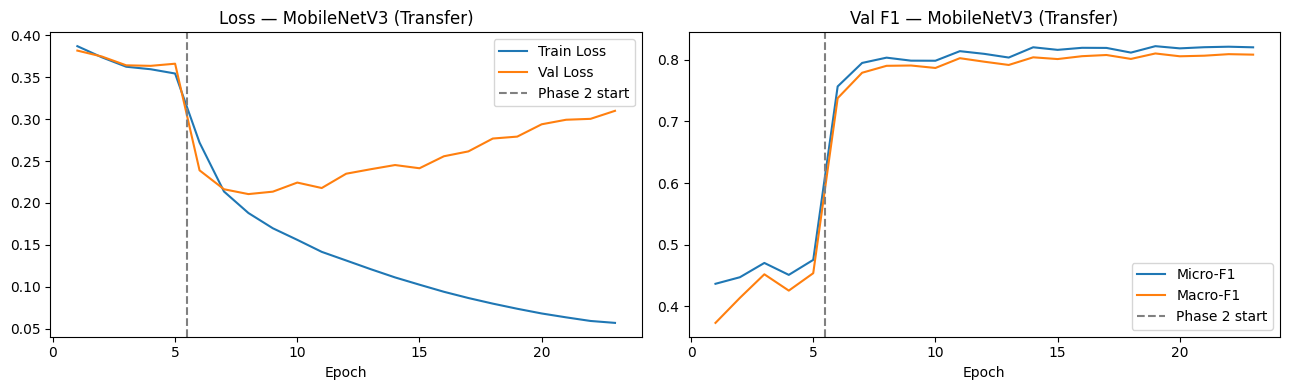

In [16]:
total_ep = len(history["train_loss"])
ep = range(1, total_ep + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep, history["train_loss"], label="Train Loss")
axes[0].plot(ep, history["val_loss"],   label="Val Loss")
axes[0].axvline(PHASE1 + 0.5, color="gray", linestyle="--", label="Phase 2 start")
axes[0].set_title("Loss — MobileNetV3 (Transfer)")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(ep, history["micro_f1"], label="Micro-F1")
axes[1].plot(ep, history["macro_f1"], label="Macro-F1")
axes[1].axvline(PHASE1 + 0.5, color="gray", linestyle="--", label="Phase 2 start")
axes[1].set_title("Val F1 — MobileNetV3 (Transfer)")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=100)
plt.show()

Test evaluation

In [17]:
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded — epoch {ckpt['epoch']}  phase {ckpt['phase']}  Macro-F1={ckpt['macro_f1']:.4f}")
 
te_loss, te_micro, te_macro, te_probs, te_labels = evaluate(model, test_loader, criterion, device)
te_preds = (te_probs >= 0.5).astype(int)
 
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(te_labels, te_preds)

print(f"\n{'='*55}")
print("TEST RESULTS — MobileNetV3 (Transfer Learning)")
print(f"{'='*55}")
print(f"Loss     : {te_loss:.4f}")
print(f"Accuracy : {test_accuracy:.4f}")   
print(f"Micro-F1 : {te_micro:.4f}")
print(f"Macro-F1 : {te_macro:.4f}")

print(f"\nPer-class report:")
print(classification_report(te_labels, te_preds, target_names=CLASS_NAMES, zero_division=0))

Loaded — epoch 19  phase 2  Macro-F1=0.8102



TEST RESULTS — MobileNetV3 (Transfer Learning)
Loss     : 0.2837
Accuracy : 0.6181
Micro-F1 : 0.8194
Macro-F1 : 0.8069

Per-class report:
                  precision    recall  f1-score   support

short_sleeve_top       0.89      0.77      0.83      6160
        trousers       0.91      0.87      0.89      4716
          shorts       0.80      0.75      0.77      2067
 long_sleeve_top       0.78      0.70      0.74      2962
           skirt       0.87      0.76      0.81      3247

       micro avg       0.87      0.78      0.82     19152
       macro avg       0.85      0.77      0.81     19152
    weighted avg       0.87      0.78      0.82     19152
     samples avg       0.84      0.79      0.80     19152



ROC curves

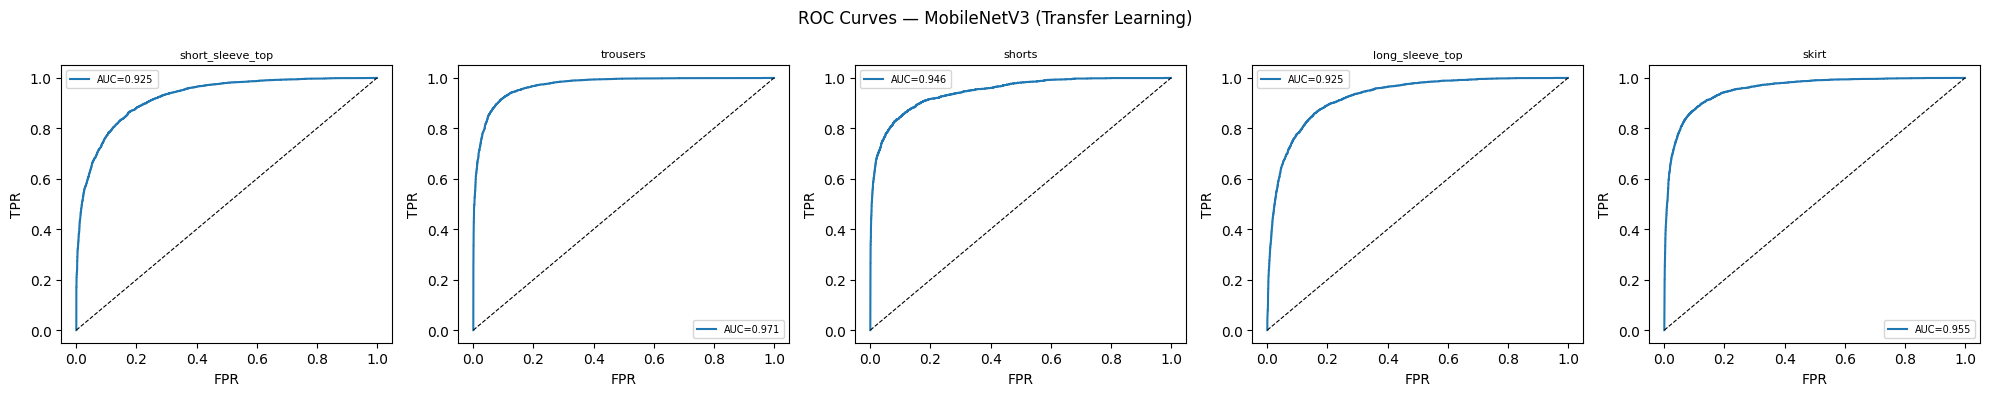

Mean AUC: 0.9443


In [ ]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
auc_list = []
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(te_labels[:, i], te_probs[:, i])
        auc = roc_auc_score(te_labels[:, i], te_probs[:, i])
        auc_list.append(auc)
        axes[i].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    except Exception:
        auc_list.append(0.0)
        axes[i].text(0.5, 0.5, "N/A", ha="center")
    axes[i].plot([0,1],[0,1],"k--", lw=0.8)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("FPR"); axes[i].set_ylabel("TPR")
    axes[i].legend(fontsize=7)
plt.suptitle("ROC Curves — MobileNetV3 (Transfer Learning)")
plt.tight_layout()
plt.savefig(CKPT_DIR / "roc_curves.png", dpi=100)
plt.show()
print(f"Mean AUC: {np.mean(auc_list):.4f}")

Threshold tuning

In [ ]:
print("\nThreshold tuning on val set:")
_, _, _, val_probs, val_true = evaluate(model, val_loader, criterion, device)
best_thresholds = []
for i in range(NUM_CLASSES):
    best_t, best_f = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        f = f1_score(val_true[:, i], (val_probs[:, i] >= t).astype(int), zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    best_thresholds.append(best_t)
    print(f"  {CLASS_NAMES[i]:<25s}: threshold={best_t:.2f}  val-F1={best_f:.4f}")
 
tuned_preds = np.stack(
    [(te_probs[:, i] >= best_thresholds[i]).astype(int) for i in range(NUM_CLASSES)], axis=1
)
print(f"\nWith tuned thresholds:")
print(f"  Micro-F1: {f1_score(te_labels, tuned_preds, average='micro', zero_division=0):.4f}")
print(f"  Macro-F1: {f1_score(te_labels, tuned_preds, average='macro', zero_division=0):.4f}")



Threshold tuning on val set:


  short_sleeve_top         : threshold=0.15  val-F1=0.8580
  trousers                 : threshold=0.25  val-F1=0.8881
  shorts                   : threshold=0.50  val-F1=0.7822
  long_sleeve_top          : threshold=0.20  val-F1=0.7464
  skirt                    : threshold=0.15  val-F1=0.8297

With tuned thresholds:
  Micro-F1: 0.8325
  Macro-F1: 0.8179


Save results

In [ ]:
results = {
    "model": "MobileNetV3-Large", "training": "transfer_learning",
    "test_loss": te_loss, "micro_f1": te_micro, "macro_f1": te_macro,
    "per_class_precision": precision_score(te_labels, te_preds, average=None, zero_division=0).tolist(),
    "per_class_recall":    recall_score(te_labels,    te_preds, average=None, zero_division=0).tolist(),
    "per_class_f1":        f1_score(te_labels,        te_preds, average=None, zero_division=0).tolist(),
    "auc_per_class":       auc_list,
    "best_thresholds":     best_thresholds,
    "class_names":         CLASS_NAMES,
}
with open(CKPT_DIR / "results.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\nAll outputs saved to: {CKPT_DIR}")
print(f"Model saved at      : {CKPT_DIR / 'best_model.pt'}")



All outputs saved to: /kaggle/working/mobilenet_transfer
Model saved at      : /kaggle/working/mobilenet_transfer/best_model.pt
